In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pandas as pd

In [ ]:
ri_matches = pd.read_csv('../dataset/ri_matches_awards_2024-12-8_3-53-3.csv')
print(ri_matches.head())

Summary Statistics:

In [ ]:
print("Initial data shape:", ri_matches.shape)
print("\nFirst 5 rows:")
print(ri_matches.head())

print("\nData info:")
ri_matches.info()

print("\nSummary statistics:")
print(ri_matches.describe(include='all').T)

print("\nMissing values per column:")
print(ri_matches.isnull().sum())

Cleaning Data


In [31]:
columns_to_drop = [
    'awardgoverningsocietyid', 
    'awardid', 
    'awardreceivedid', 
    'AAUID',
    'clientfacultyid',
    'orcid'
]

df_cleaned = ri_matches.drop(columns=columns_to_drop)

#Date Format
df_cleaned['asofdate'] = pd.to_datetime(df_cleaned['asofdate'], errors='coerce')
df_cleaned['asofdate_formatted'] = df_cleaned['asofdate'].dt.strftime('%Y-%m-%d')
ri_matches_clean = df_cleaned.drop(columns=['asofdate'])

ri_matches_clean.to_csv('../dataset/cleaned_ri_matches.csv', index=False)

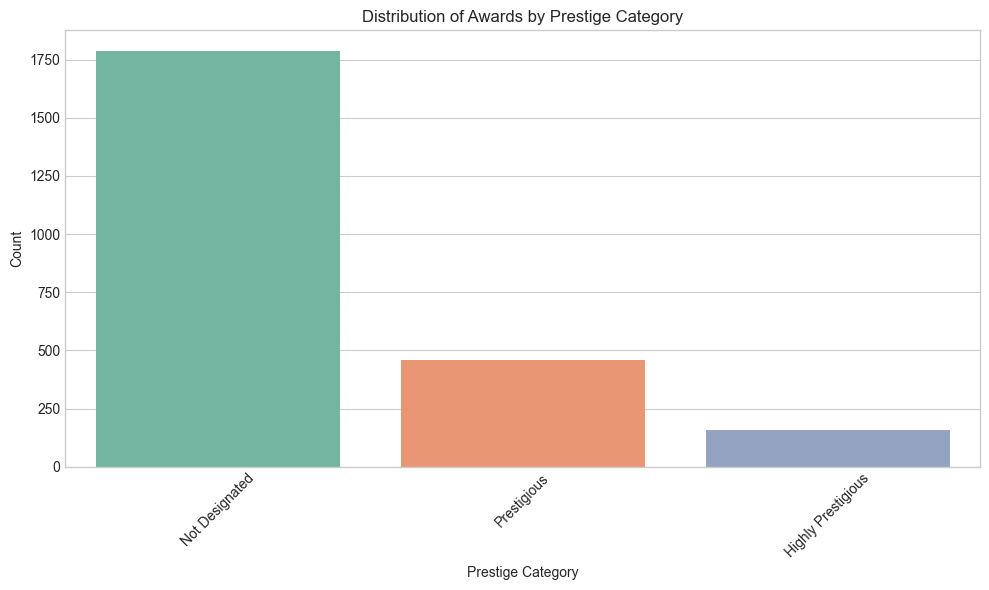

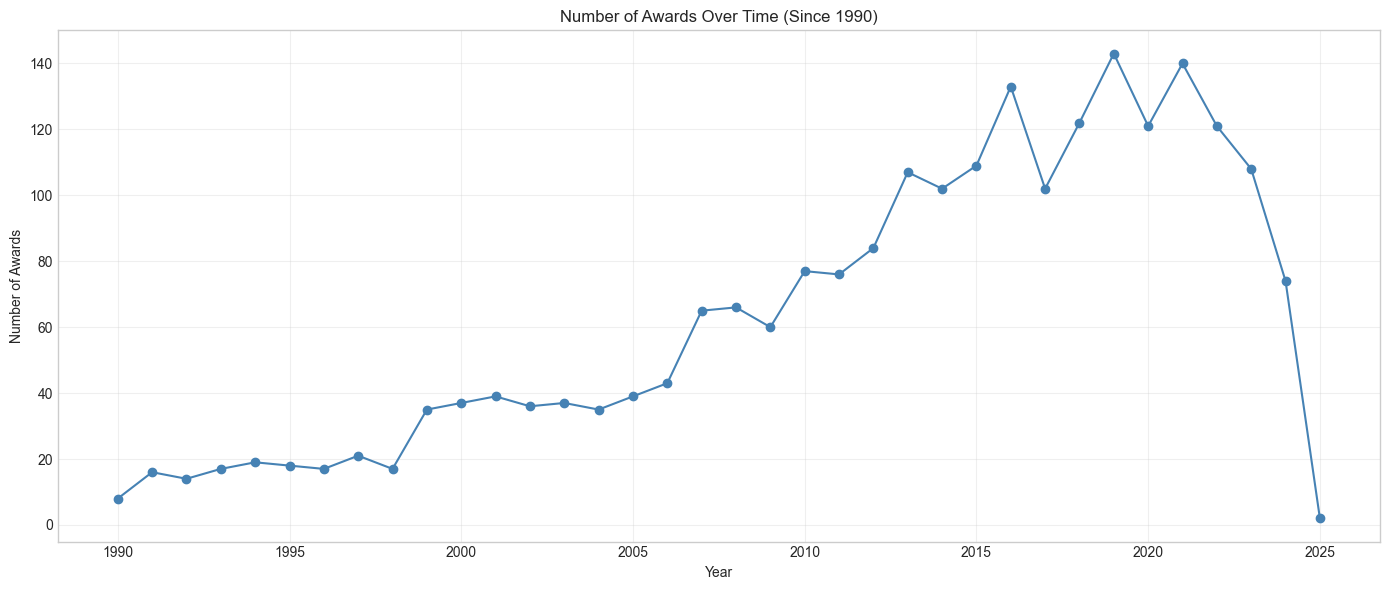

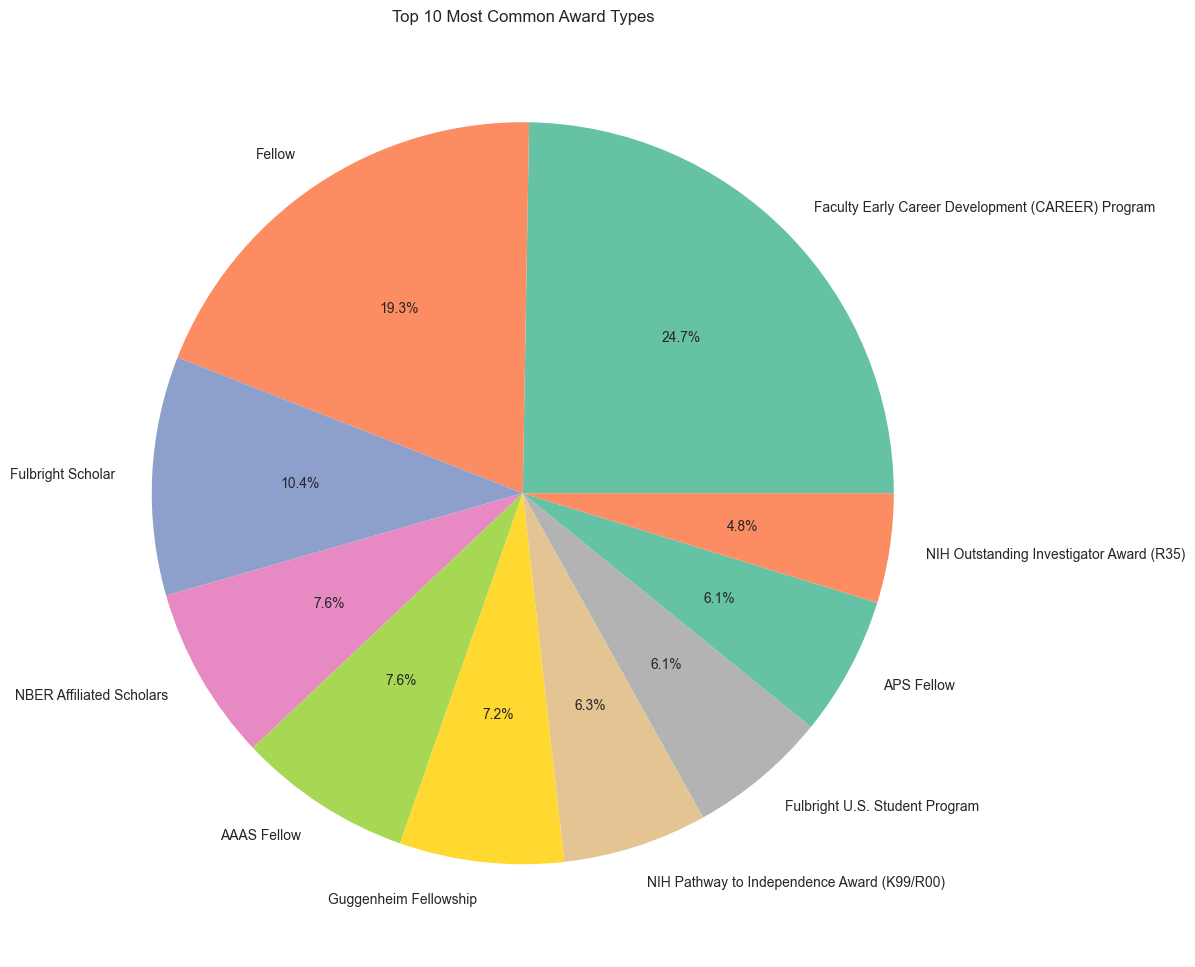

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(x=ri_matches['prestige'])
plt.title('Distribution of Awards by Prestige Category')
plt.xlabel('Prestige Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

recent_years = ri_matches[ri_matches['awardreceivedawardyear'] >= 1990].copy()
year_counts = recent_years.groupby('awardreceivedawardyear').size()

plt.figure(figsize=(14, 6))
year_counts.plot(kind='line', marker='o', color='steelblue')
plt.title('Number of Awards Over Time (Since 1990)')
plt.xlabel('Year')
plt.ylabel('Number of Awards')
plt.grid(True, alpha=0.3)
plt.tight_layout()

top_awards = ri_matches['awardname'].value_counts().head(10)
plt.figure(figsize=(12, 12))
top_awards.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 10 Most Common Award Types')
plt.ylabel('')
plt.tight_layout()

Notes:

Row #1395:
U93461629B
What is B?

Row #2025:
2023-6-AA

Row #2170:
2023-3-AA

Row #2383:
2023-5-AA

Row #2404:
Missing ID